# SG-Derived Input Features for the MM Nowcast

Can SG information improve the NN's same-week estimate of MM position changes? Both kinds of feature below come from the SG-fitted momentum network in [`predict_sg_index.ipynb`](predict_sg_index.ipynb), which explains each day's SG Trend return from that day's energy returns:

$$\widehat{r}^{SG}_d = c + \sum_m h_\theta(x_{m,d-1})\,u_{m,d}.$$

$h_\theta$ is the network's risk-scaled energy position, set from the momentum inputs $x$ at the previous close, with one set of weights for all six markets and refitted each year on the previous four years. $u_{m,d}$ is market $m$'s daily price change divided by its daily volatility. The first kind of feature uses what this fit **explains** (the positions it implies); the second uses what it **misses** (the residual).

### 1. SG-implied CTA flow (`sg_flow`)

If CTAs traded the positions that best explain their P&L, how much would they have bought or sold this week?

$$F^{SG}_{m,t} = s\left[\frac{h_\theta(x_{m,t})}{\nu_{m,t}} - \frac{h_\theta(x_{m,t-1})}{\nu_{m,t-1}}\right]$$

- **Contracts from risk.** Dividing by $\nu$, the annualized price volatility, turns a risk position into a contract-like quantity: CTAs size by risk, so they hold fewer contracts when volatility is high. The flow therefore includes both signal changes and volatility-driven resizing.
- **One model per change.** Both endpoints use the model for week $t$'s year, so a change never mixes two fits.
- **Arbitrary units.** $s$ is the SG return scale; the correction regression maps the feature to contracts.

It is the SG counterpart of the NN's own trend flow, $\sigma_{m,t}(T_{m,t}-T_{m,t-1})$, learned from CTA P&L instead of COT positions.

### 2. Daily SG residual features

What does the SG index do that energy momentum cannot explain? The daily residual is

$$\varepsilon_d = r^{SG}_d - \widehat{r}^{SG}_d,$$

and we summarize it over the days between consecutive COT as-of dates, $(t-1,\,t]$:

| Feature | Formula | By market? | Intended reading |
|---|---|---|---|
| Weekly residual (`resid_week`) | $\sum_d \varepsilon_d$ | No, the same for all six | CTAs did better or worse overall than energy momentum implies |
| Residual × market return (`resid_x_return`) | $\sum_d \varepsilon_d\,u_{m,d}$ | Yes | Positive when SG over-earned on days market $m$ rose, or under-earned when it fell: CTAs held more of $m$ than the model says |
| 20-day residual beta (`resid_beta20`) | $\sum \varepsilon_d u_{m,d} / \sum u_{m,d}^2$ over the last 20 trading days | Yes | The same exposure gap, estimated as a smoothed slope |

The last two keep only the part of the residual that moves with each energy market. Section 3 also feeds the residuals **day by day** as tabular inputs (the last 5 or 10 trading days, each its own column), both for the same-week nowcast and as a one-week-ahead forecast. With six energy markets, most of $\varepsilon$ is CTA P&L from rates, FX and equities rather than discretionary energy flow.

### How the features are used

All features are known by Tuesday's close. The NN itself is unchanged: as in the carry notebook, each week a ridge regression (penalty 0.1) of the NN's previous 104 out-of-sample errors, divided by the position scale $\sigma$, on the standardized feature(s) gives a correction. It is fitted per market or pooled across markets, and $\sigma \times$ the fitted correction is added to the NN prediction.

### Result

**Neither improves the nowcast.** SG-implied flow correlates only 0.15–0.31 with weekly MM changes, against 0.56–0.71 for the NN's own trend flow. Adding it, or any weekly feature built from the daily SG residual, lowers R² by 0.2–5.4 pp relative to the original NN's **44.90%**. Feeding the residuals day by day does not help either: it lowers the nowcast R² by 2.3–21.7 pp, and as a one-week-ahead forecast it lowers R² from 5.87% (last week's MM change alone) to 0.91%. No ridge penalty changes this. The SG index is useful for *labelling* MM positions (see [`nn_benchmark.ipynb`](nn_benchmark.ipynb)), not for *predicting* weekly changes.

This is one of three SG notebooks, meant to be read in order:

1. [`nn_benchmark.ipynb`](nn_benchmark.ipynb): does the NN's trend component earn CTA-like P&L? SG returns are used only as a **benchmark**.
2. [`predict_sg_index.ipynb`](predict_sg_index.ipynb): the paper's momentum layer with SG returns as the **training target**.
3. [`sg_input_feature.ipynb`](sg_input_feature.ipynb): SG-derived **input features** as corrections to the MM nowcast.

Helpers are in [`src/sg_cta.py`](src/sg_cta.py).

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'working_ideas' else Path.cwd()
PROJECT_ROOT = REPO_ROOT / 'paper_replication'
sys.path[:0] = [str(PROJECT_ROOT / 'src'), str(REPO_ROOT / 'working_ideas' / 'src')]

import torch
from paper_replication.config import HORIZONS, ReplicationConfig
from paper_replication.evaluate import run_replication
import sg_cta as sg
from sg_cta import KEYS, MARKETS, PNL_LABELS

OUTPUT = PROJECT_ROOT / 'outputs' / 'sg_input_feature'
OUTPUT.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(1)
config = ReplicationConfig(data_dir=PROJECT_ROOT / 'data_required', basis='futures_only',
                           train_weeks=104, seed=7)
COLORS = {'trend': '#277f8e', 'bias': '#b7782c', 'rule': '#96587e', 'sg': '#596eaf'}
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

## Data

We need three inputs: the baseline NN predictions, its trend/bias decomposition (see [`nn_benchmark.ipynb`](nn_benchmark.ipynb)), and the SG-fitted network refitted exactly as in [`predict_sg_index.ipynb`](predict_sg_index.ipynb).

In [2]:
reference = run_replication(config, progress=False)
baseline = reference['predictions'].copy()
panel = reference['weekly_panel']
daily = sg.add_trend_rule(reference['daily_features'])
sg_levels = sg.load_sg_log_levels(config.data_dir)
decomposition, _ = sg.run_decomposition(panel, config)

daily_data = sg.daily_sg_arrays(daily, sg_levels, 'SG Trend')
sg_run = sg.rolling_sg_fit(daily_data, config)
print(f"SG fit, out-of-sample daily correlation: {sg_run['fitted'].corr(sg_run['actual']):.3f}")

SG fit, out-of-sample daily correlation: 0.331


## 1. Does SG-implied CTA flow explain MM changes?

We turn the SG-fitted position from [`predict_sg_index.ipynb`](predict_sg_index.ipynb) into a contract-like quantity, $h_{m,t}/\nu_{m,t}$ (risk-scaled positions buy fewer contracts when volatility rises), and take its weekly change. Both endpoints use the model for the current week's year, so a change never mixes two fits. We then ask two questions:

1. How closely does this SG-implied flow track actual MM changes, compared with the NN's own trend flow $\sigma_{m,t}(T_{m,t}-T_{m,t-1})$?
2. Does it improve the NN nowcast? We use the error-correction design of the carry notebook: a ridge regression (penalty 0.1) of the previous 104 genuine out-of-sample NN errors, divided by the position scale, on the standardized feature. We fit one regression per market and one pooled across markets. All scores use the carry notebook's 2,820 market-weeks from 2017–2025.

In [3]:
flows = (baseline.merge(decomposition, on=KEYS)
         .merge(sg.sg_implied_flow(panel, daily, sg_run['models']), on=KEYS, how='left'))
flows['nn_trend_flow'] = flows['mm_std_lag'] * (flows['trend_cur'] - flows['trend_prev'])
print('Correlation with actual weekly MM change, 2015–2025')
display(sg.flow_correlations(flows).round(2))

results = {'Original NN': sg.score(sg.common_sample(baseline))}
for pooled, tag in [(False, 'per market'), (True, 'pooled')]:
    results[f'NN + SG-implied flow ({tag})'] = sg.score(
        sg.common_sample(sg.error_correction(flows, ['sg_flow'], pooled)), 'corrected_change')
display(pd.DataFrame(results).T.drop(columns='Observations').round(2))

Correlation with actual weekly MM change, 2015–2025


,NN trend flow,SG-implied flow,NN trend flow vs SG-implied flow
market,,,
WTI,0.65,0.15,0.24
BRENT,0.71,0.21,0.20
GASOIL,0.69,0.28,0.25
HEATOIL,0.59,0.31,0.34
RBOB,0.56,0.29,0.33
NATGAS,0.66,0.24,0.21


,R² (%),Direction (%),MAE (contracts)
Original NN,44.90,72.70,10793.88
NN + SG-implied flow (per market),42.37,72.09,11054.83
NN + SG-implied flow (pooled),44.03,72.87,10875.03


**Reading.** SG-implied flow is positively related to MM changes in every market, but far more weakly than the NN's trend flow, and only moderately related to it (0.20–0.34). As a correction it lowers R², by 0.88 pp pooled and 2.53 pp per market. Weekly MM changes are dominated by faster momentum than the SG-fitted positions carry. Any SG information that is also in our momentum inputs is already used by the NN, and the remainder is estimated too noisily to help.

## 2. The daily SG residual as a discretionary signal

The idea: fit each day's SG return from that day's energy moves ([`predict_sg_index.ipynb`](predict_sg_index.ipynb)), and treat what is left,

$$\varepsilon_d = r^{SG}_d-\widehat{r}^{SG}_d,$$

as information that momentum does not explain. We engineer it into weekly features over the days between consecutive COT as-of dates, $(t-1,\,t]$, all known by Tuesday's close:

| Feature | Definition | Intended reading |
|---|---|---|
| Weekly residual | $\sum_{d}\varepsilon_d$ | CTAs did better or worse than energy momentum implies |
| Residual × market return | $\sum_{d}\varepsilon_d\,u_{m,d}$ | CTAs earned (lost) extra in market $m$, so they held more (less) of it than the model says |
| 20-day residual beta | $\sum\varepsilon_d u_{m,d}/\sum u_{m,d}^2$ over 20 days | The same exposure gap, smoothed |

Here $u_{m,d}=\Delta P_{m,d}/(\nu_{m,d}/\sqrt{252})$ is the market's volatility-scaled daily return.

**Interpretation caveat.** $\varepsilon$ is mostly CTA P&L from rates, FX and equity futures, which our six energy markets cannot explain. It is not a direct measure of discretionary energy flow. The second and third features target the energy part by keeping only the component that moves with each market's return.

The residual is out of sample: each day uses the model trained before its year. The test is the same error correction as Section 1.

In [4]:
residual = (sg_run['actual'] - sg_run['fitted']).rename('residual')
risk_returns = pd.DataFrame(daily_data['u'], index=daily_data['dates'], columns=MARKETS).loc[residual.index]
as_of = panel.groupby('report_week_tuesday')['report_date'].max().sort_index()
design = flows.merge(sg.residual_features(residual, risk_returns, as_of), on=KEYS, how='left')

RESIDUAL_FEATURES = {'resid_week': 'Weekly residual', 'resid_x_return': 'Residual × market return',
                     'resid_beta20': '20-day residual beta'}
change = design['actual_change'] / design['mm_std_lag']
error = (design['actual_change'] - design['predicted_change']) / design['mm_std_lag']
display(pd.DataFrame({'With MM change': design[list(RESIDUAL_FEATURES)].corrwith(change),
                      'With NN error': design[list(RESIDUAL_FEATURES)].corrwith(error)})
        .rename(index=RESIDUAL_FEATURES).round(3))

for pooled, tag in [(False, 'per market'), (True, 'pooled')]:
    for column, label in RESIDUAL_FEATURES.items():
        results[f'NN + {label.lower()} ({tag})'] = sg.score(
            sg.common_sample(sg.error_correction(design, [column], pooled)), 'corrected_change')
    results[f'NN + all SG features ({tag})'] = sg.score(sg.common_sample(
        sg.error_correction(design, ['sg_flow'] + list(RESIDUAL_FEATURES), pooled)), 'corrected_change')

,With MM change,With NN error
Weekly residual,0.052,0.015
Residual × market return,-0.119,-0.049
20-day residual beta,-0.008,-0.013


## 3. Daily residuals as tabular inputs

Section 2 collapses each week's residuals into sums, which gives every day the same weight. Here each of the last $L$ SG trading days up to the COT as-of date (usually Tuesday) is its own column, so the regression can learn a separate weight for each day:

$$f_{m,t}=\big[\varepsilon_{t},\,\varepsilon_{t-1},\,\dots,\,\varepsilon_{t-L+1},\ \ \varepsilon_{t}u_{m,t},\,\dots,\,\varepsilon_{t-L+1}u_{m,t-L+1}\big].$$

Lag 0 is the as-of day, and $u_{m,d}$ is market $m$'s volatility-scaled daily return. That gives $2L$ features per market; $L=5$ is roughly one week, and we also try $L=10$.

We use the table in two ways, each with the same rolling ridge as before (previous 104 weeks, penalty 0.1, standardized features, no intercept):

| Use | Features from | Target | Models |
|---|---|---|---|
| **Same-week nowcast** | Days up to this Tuesday | This Tuesday's MM change | Residual days alone; NN + residual days (per market, pooled) |
| **One-week-ahead forecast** | Days up to last Tuesday | This Tuesday's MM change | Last week's MM change alone (known on Friday, before this week); plus last week's residual days; NN + last week's residual days |

The standalone models predict $\Delta MM/\sigma$ directly; the NN versions correct the NN's normalized errors, as in Sections 1–2. All rows are scored on the same market-weeks.

In [5]:
prev_change = panel[KEYS + ['actual_change']].rename(
    columns={'report_week_tuesday': 'previous_report_week', 'actual_change': 'previous_change'})
tabular = baseline.merge(prev_change, on=['previous_report_week', 'market'], how='left')
tabular['normalized_change'] = tabular['actual_change'] / tabular['mm_std_lag']
tabular['normalized_error'] = (tabular['actual_change'] - tabular['predicted_change']) / tabular['mm_std_lag']
tabular['previous_change_scaled'] = tabular['previous_change'] / tabular['mm_std_lag']

specs, needed = {}, ['previous_change']
for lags in [5, 10]:
    table = sg.daily_residual_table(residual, risk_returns, as_of, lags).add_suffix(f'_L{lags}')
    table = table.rename(columns={f'report_week_tuesday_L{lags}': 'report_week_tuesday', f'market_L{lags}': 'market'})
    now_cols = [f'{c}_L{lags}' for c in sg.residual_columns(lags)]
    prev_cols = [f'{c}_prev' for c in now_cols]
    tabular = (tabular.merge(table, on=KEYS, how='left')
               .merge(table.rename(columns={'report_week_tuesday': 'previous_report_week'}),
                      on=['previous_report_week', 'market'], how='left', suffixes=('', '_prev')))
    needed += now_cols + prev_cols
    specs.update({
        f'Nowcast: residual days alone (L={lags})': (now_cols, 'normalized_change', None, True),
        f'Nowcast: NN + residual days, per market (L={lags})': (now_cols, 'normalized_error', 'predicted_change', False),
        f'Nowcast: NN + residual days, pooled (L={lags})': (now_cols, 'normalized_error', 'predicted_change', True),
        f"Forecast: last week's change + residual days (L={lags})": (['previous_change_scaled'] + prev_cols, 'normalized_change', None, True),
        f"Forecast: NN + last week's residual days, pooled (L={lags})": (prev_cols, 'normalized_error', 'predicted_change', True),
    })
specs["Forecast: last week's change alone"] = (['previous_change_scaled'], 'normalized_change', None, True)

tabular_predictions, tabular_coefs = {}, {}
for name, (columns, target, base, pooled) in specs.items():
    tabular_predictions[name], tabular_coefs[name] = sg.rolling_ridge(tabular, columns, target, base, pooled)

# Score every model on the same market-weeks: 2017-2025, all features available, all models fitted.
keys = sg.common_sample(tabular.dropna(subset=needed)).set_index(KEYS).index
for frame in tabular_predictions.values():
    keys = keys.intersection(frame.set_index(KEYS).index)
on_keys = lambda frame: frame.set_index(KEYS).loc[keys].reset_index()
tabular_summary = pd.DataFrame(
    {'Original NN': sg.score(on_keys(baseline))}
    | {name: sg.score(on_keys(frame), 'prediction') for name, frame in tabular_predictions.items()}).T
tabular_summary['ΔR² vs NN (pp)'] = tabular_summary['R² (%)'] - tabular_summary.loc['Original NN', 'R² (%)']
order = ['Original NN'] + sorted([n for n in tabular_summary.index if n.startswith('Nowcast')]) \
        + sorted([n for n in tabular_summary.index if n.startswith('Forecast')])
print(f'{len(keys):,} market-weeks, {keys.get_level_values(0).min():%Y-%m-%d} to {keys.get_level_values(0).max():%Y-%m-%d}')
display(tabular_summary.loc[order].drop(columns='Observations').round(2))

2,820 market-weeks, 2017-01-03 to 2025-12-30


,R² (%),Direction (%),MAE (contracts),ΔR² vs NN (pp)
Original NN,44.90,72.70,10793.88,0.00
"Nowcast: NN + residual days, per market (L=10)",23.26,68.69,12467.46,-21.65
"Nowcast: NN + residual days, per market (L=5)",34.54,70.35,11598.04,-10.37
"Nowcast: NN + residual days, pooled (L=10)",39.36,70.43,11288.84,-5.55
"Nowcast: NN + residual days, pooled (L=5)",42.58,71.60,10951.05,-2.32
Nowcast: residual days alone (L=10),-11.64,49.33,15181.66,-56.55
Nowcast: residual days alone (L=5),-6.43,50.07,14765.74,-51.33
"Forecast: NN + last week's residual days, pooled (L=10)",40.04,71.03,11251.67,-4.86
"Forecast: NN + last week's residual days, pooled (L=5)",42.69,71.35,11024.78,-2.22
Forecast: last week's change + residual days (L=10),-5.87,54.89,14793.40,-50.78


**Penalty sensitivity.** A penalty of 0.1 may be too weak for 10–20 columns. We refit the pooled versions with heavier ridge penalties. This is a robustness check, not a selection: it asks whether *any* penalty lets the residual days beat the comparison model.

In [6]:

sensitivity = {}
for penalty in [0.1, 1, 10, 100]:
    for label, name in [('Nowcast: NN + residual days, pooled', 'Nowcast: NN + residual days, pooled (L=5)'),
                        ("Forecast: last week's change + residual days", "Forecast: last week's change + residual days (L=5)")]:
        columns, target, base, pooled = specs[name]
        frame, _ = sg.rolling_ridge(tabular, columns, target, base, pooled, penalty=penalty)
        sensitivity[(label, penalty)] = sg.score(on_keys(frame), 'prediction')['R² (%)']
sensitivity = pd.Series(sensitivity).unstack()
sensitivity['Comparison model'] = [tabular_summary.loc["Forecast: last week's change alone", 'R² (%)'],
                                   tabular_summary.loc['Original NN', 'R² (%)']]
print('R² (%) by ridge penalty, L = 5')
display(sensitivity.round(2))


R² (%) by ridge penalty, L = 5


,0.1,1.0,10.0,100.0,Comparison model
Forecast: last week's change + residual days,0.91,3.25,1.07,0.13,5.87
"Nowcast: NN + residual days, pooled",42.58,44.20,44.89,44.91,44.90


Which days does the regression lean on? The chart averages the standardized coefficients of the pooled NN correction over all weekly refits, for $L=10$.

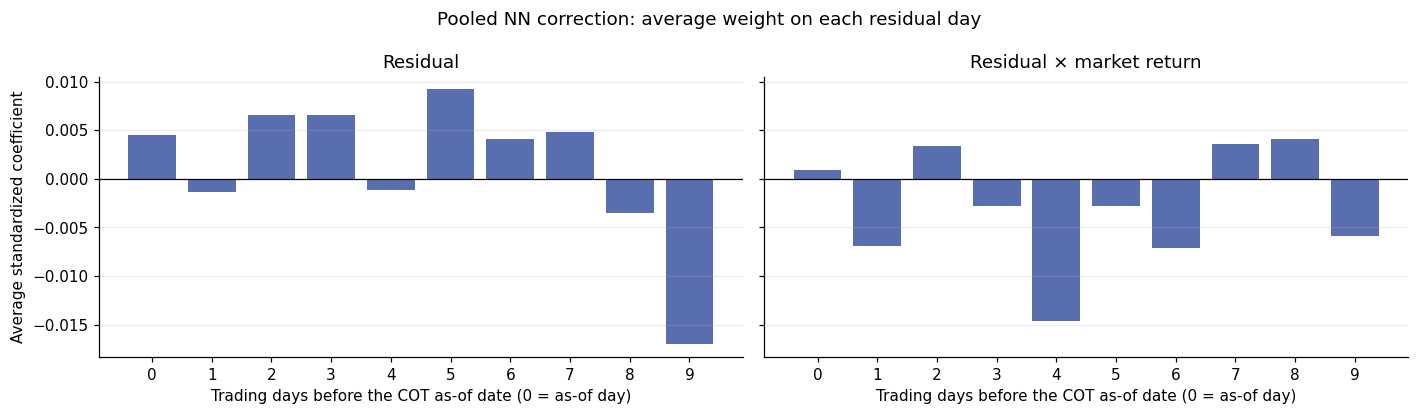

In [7]:
coefs = tabular_coefs['Nowcast: NN + residual days, pooled (L=10)'].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, stem, title in [(axes[0], 'resid_lag', 'Residual'), (axes[1], 'resid_x_return_lag', 'Residual × market return')]:
    values = [coefs[f'{stem}{k}_L10'] for k in range(10)]
    ax.bar(range(10), values, color=COLORS['sg'])
    ax.axhline(0, color='black', lw=.8)
    ax.set(title=title, xlabel='Trading days before the COT as-of date (0 = as-of day)', xticks=range(10))
    ax.grid(alpha=.25, axis='y')
axes[0].set_ylabel('Average standardized coefficient')
fig.suptitle('Pooled NN correction: average weight on each residual day')
fig.tight_layout()
fig.savefig(OUTPUT / 'residual_day_coefficients.png', dpi=160)
plt.show()

**Reading.** Keeping the days separate does not help; it makes things worse, and more so with more columns:

- **Nowcast.** On their own, the residual days predict weekly MM changes worse than predicting no change (R² −6.4% for $L=5$). As a correction, the NN falls from 44.90% to 42.58% (pooled, $L=5$) and to 23.26% (per market, $L=10$), which is overfitting of 20 columns to 104 weeks.
- **One-week-ahead forecast.** Last week's MM change alone gives 5.87% R²; adding last week's residual days lowers it to 0.91% ($L=5$).
- **Penalty.** No ridge penalty rescues either version. Heavier penalties only shrink the correction to zero, so the nowcast converges to the NN (44.91% vs 44.90% at penalty 100), and the forecast stays below last week's change alone.
- **Day weights.** The pooled coefficients are tiny (below 0.02 in standardized units) and change sign from day to day, with no extra weight on the as-of day. There is no timing structure to learn.

Given the caveat in Section 2, this is what we would expect if the residual mostly reflects CTA P&L outside energy: day-level detail adds noise, not information about discretionary energy flow.

## Results together

In [8]:
summary = pd.DataFrame(results).T
summary['ΔR² vs NN (pp)'] = summary['R² (%)'] - summary.loc['Original NN', 'R² (%)']
display(summary.drop(columns='Observations').round(2))
print('Daily residuals as tabular inputs (Section 3, its own common sample)')
display(tabular_summary.loc[order].drop(columns='Observations').round(2))

,R² (%),Direction (%),MAE (contracts),ΔR² vs NN (pp)
Original NN,44.90,72.70,10793.88,0.00
NN + SG-implied flow (per market),42.37,72.09,11054.83,-2.53
NN + SG-implied flow (pooled),44.03,72.87,10875.03,-0.88
NN + weekly residual (per market),43.64,71.67,10930.79,-1.26
NN + residual × market return (per market),43.94,72.87,10919.80,-0.97
NN + 20-day residual beta (per market),44.27,72.06,10882.31,-0.63
NN + all SG features (per market),39.49,71.28,11322.83,-5.41
NN + weekly residual (pooled),44.25,72.66,10840.10,-0.66
NN + residual × market return (pooled),44.71,72.73,10833.53,-0.20
NN + 20-day residual beta (pooled),44.54,72.59,10826.16,-0.36


Daily residuals as tabular inputs (Section 3, its own common sample)


,R² (%),Direction (%),MAE (contracts),ΔR² vs NN (pp)
Original NN,44.90,72.70,10793.88,0.00
"Nowcast: NN + residual days, per market (L=10)",23.26,68.69,12467.46,-21.65
"Nowcast: NN + residual days, per market (L=5)",34.54,70.35,11598.04,-10.37
"Nowcast: NN + residual days, pooled (L=10)",39.36,70.43,11288.84,-5.55
"Nowcast: NN + residual days, pooled (L=5)",42.58,71.60,10951.05,-2.32
Nowcast: residual days alone (L=10),-11.64,49.33,15181.66,-56.55
Nowcast: residual days alone (L=5),-6.43,50.07,14765.74,-51.33
"Forecast: NN + last week's residual days, pooled (L=10)",40.04,71.03,11251.67,-4.86
"Forecast: NN + last week's residual days, pooled (L=5)",42.69,71.35,11024.78,-2.22
Forecast: last week's change + residual days (L=10),-5.87,54.89,14793.40,-50.78


No SG-based correction beats the original NN on the 2,820 common market-weeks, whether the residual enters as weekly summaries or day by day. The best, the pooled residual × market return, is 0.20 pp below. The daily residual features are almost uncorrelated with the NN's errors (|correlation| ≤ 0.05), so there is little for the correction to learn. This is expected given the caveat in Section 2: with only six energy markets, most of the residual is CTA P&L from other asset classes, not discretionary energy flow.

## Next step

We will use the SG data where it helps, as a check on the CTA/discretionary labels, and not as a nowcast feature for now. Three extensions could change the conclusion:

1. **Add non-energy futures** (rates, FX, equity indices, metals) to explain the roughly 85% of weekly SG variance that energy P&L leaves unexplained. Only then does the daily residual isolate energy.
2. **Use SG as a training signal rather than an input.** Add an SG P&L term to the NN loss, so the shared trend layer must explain both MM positions and CTA P&L, and the bias cannot absorb trend-following.
3. **Extend horizons beyond 250 days,** since the SG fit puts its largest weight on the longest horizon available.

## Save results

In [9]:
pd.DataFrame({'sg_fitted': sg_run['fitted'], 'sg_actual': sg_run['actual'],
              'residual': residual}).to_csv(OUTPUT / 'sg_daily_residual.csv')
design.to_csv(OUTPUT / 'sg_feature_design.csv', index=False)
summary.to_csv(OUTPUT / 'nowcast_summary.csv')
tabular_summary.loc[order].to_csv(OUTPUT / 'tabular_residual_summary.csv')

## References

- Sun, Bouchouev and Fattouh (2026), [Momentum Trading and Managed Money Positioning in Energy](https://www.oxfordenergy.org/wpcms/wp-content/uploads/2026/03/Insight-177-Money-Positioning-in-Energy.pdf), OIES Insight 177, §§1 and 3.
- Société Générale Prime Services, [SG Trend Index methodology](https://wholesale.banking.societegenerale.com/fileadmin/indices_feeds/SG_Trend_Index_Methodology.pdf) and [SG Trend Indicator methodology](https://wholesale.banking.societegenerale.com/fileadmin/indices_feeds/SG_Trend_Indicator_Methodology_Summary.pdf).
- CFTC, [Disaggregated COT explanatory notes](https://www.cftc.gov/MarketReports/CommitmentsofTraders/DisaggregatedExplanatoryNotes/index.htm): definition of Managed Money.
- Boos and Grob (2023), [Tracking speculative trading](https://www.sciencedirect.com/science/article/pii/S1386418122000635), *Journal of Financial Markets* 64.
- Roncalli and Teiletche (2008), [An Alternative Approach to Alternative Beta](https://doi.org/10.2139/ssrn.1035521): Kalman-filter replication of hedge fund indices.
- Benhamou, Ohana, Guez and Jacquot (2026), [Decoding CTA Allocations by Trend Horizon](https://rpc.cfainstitute.org/blogs/enterprising-investor/2026/decoding-cta-allocations-by-trend-horizon), CFA Institute.